In [47]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
df = pd.read_csv('test.csv', sep=';')

In [56]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [57]:
df.shape

(4521, 17)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [59]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [60]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df['job'].value_counts()

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

EDA (EXPLORATORY DATA ANALYSIS)

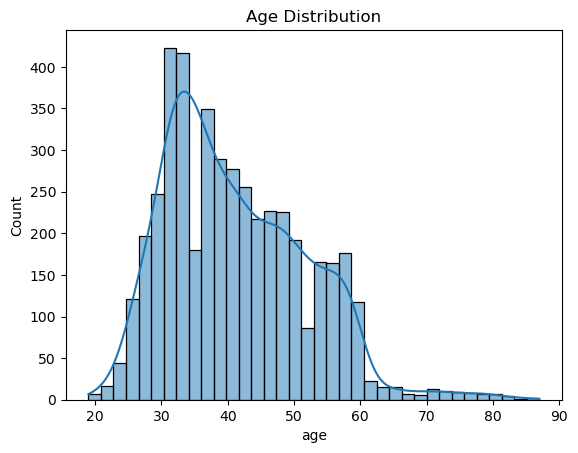

In [63]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

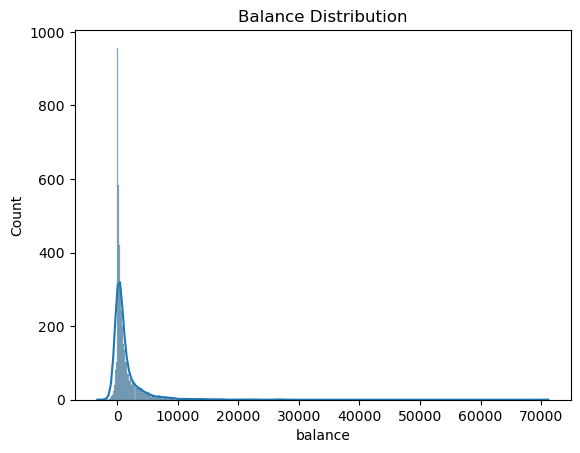

In [64]:
sns.histplot(df['balance'], kde=True)
plt.title("Balance Distribution")
plt.show()

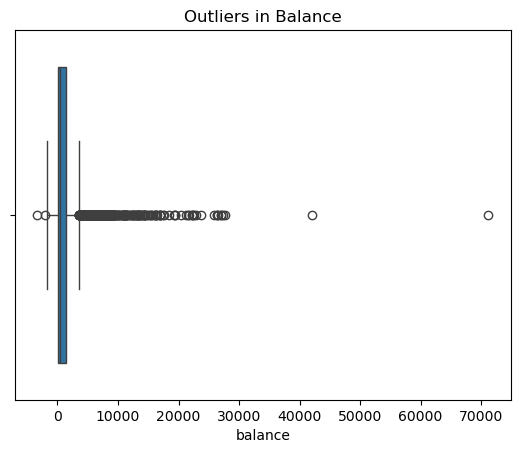

In [65]:
sns.boxplot(x=df['balance'])
plt.title("Outliers in Balance")
plt.show()

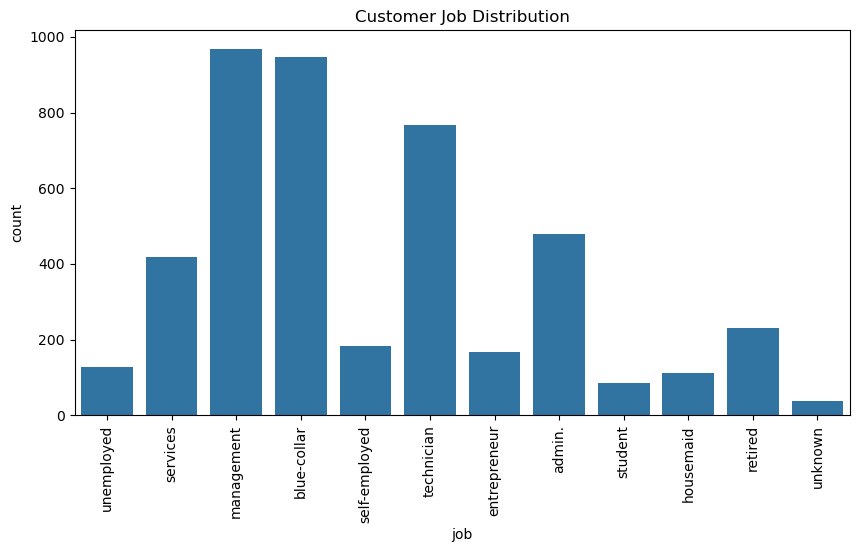

In [66]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', data=df)
plt.xticks(rotation=90)
plt.title("Customer Job Distribution")
plt.show()

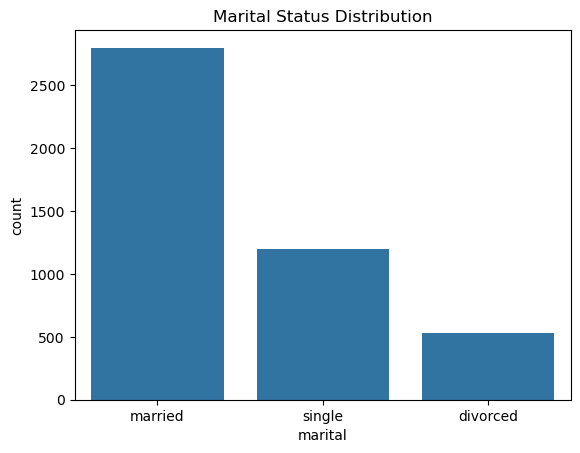

In [67]:
sns.countplot(x='marital', data=df)
plt.title("Marital Status Distribution")
plt.show()

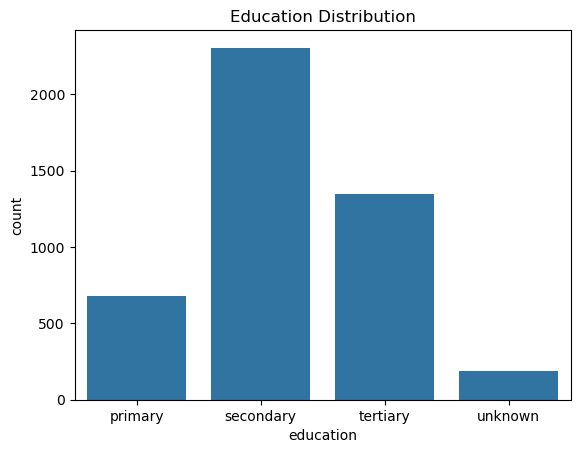

In [68]:
sns.countplot(x='education', data=df)
plt.title("Education Distribution")
plt.show()

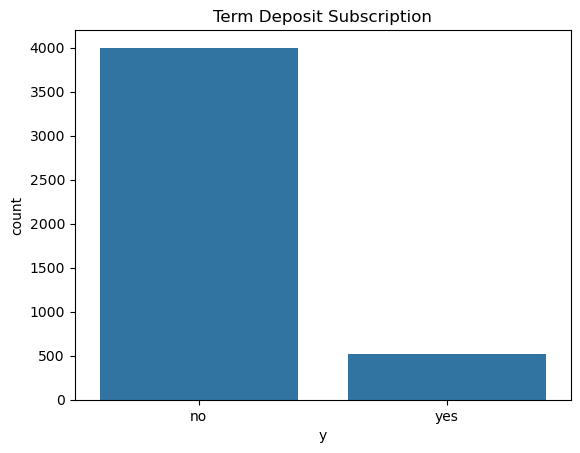

In [69]:
sns.countplot(x='y', data=df)
plt.title("Term Deposit Subscription")
plt.show()

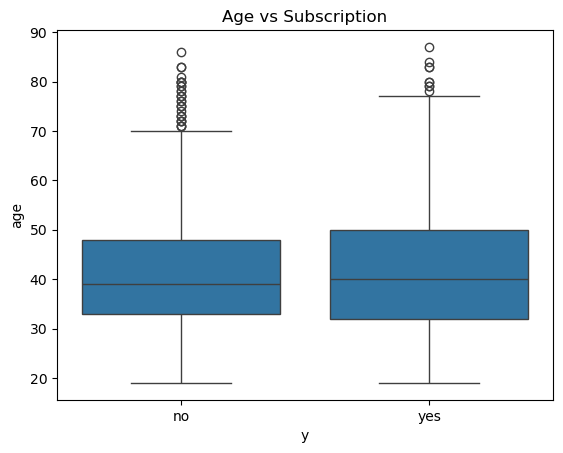

In [70]:
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

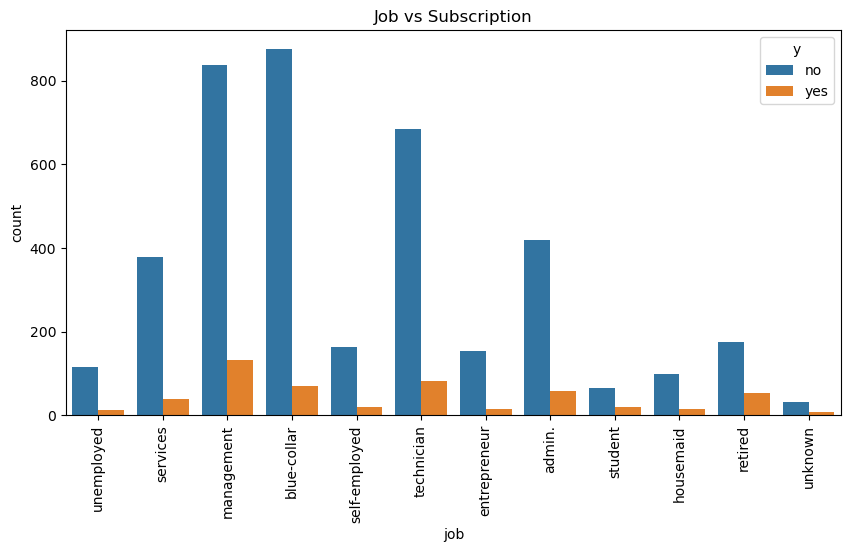

In [71]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=90)
plt.title("Job vs Subscription")
plt.show()

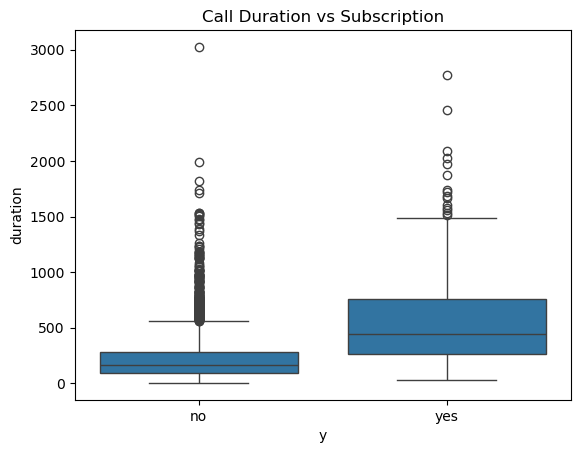

In [72]:
sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration vs Subscription")
plt.show()

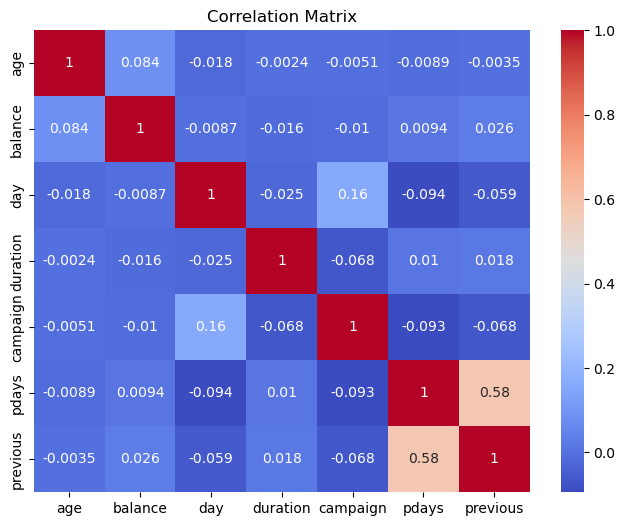

In [73]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [74]:
stat, p = stats.shapiro(df['age'])

print("Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Age data is normally distributed")
else:
    print("Age data is not normally distributed")

Statistic: 0.9595145277540517
P-value: 9.427573604574863e-34
Age data is not normally distributed


In [75]:
corr, p = stats.pearsonr(df['age'], df['balance'])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.08382014224477763
P-value: 1.658480874632515e-08


In [76]:
yes = df[df['y'] == 'yes']['age']
no = df[df['y'] == 'no']['age']

stat, p = stats.ttest_ind(yes, no)

print("T-statistic:", stat)
print("P-value:", p)

T-statistic: 3.034315524024384
P-value: 0.002424535817380578


In [77]:
# Recalculate important statistics used in analysis

total_customers = len(df)
subscribed = (df['y'] == 'yes').sum()
not_subscribed = (df['y'] == 'no').sum()

avg_age = df['age'].mean()
avg_balance = df['balance'].mean()

max_balance = df['balance'].max()
min_balance = df['balance'].min()

top_job = df['job'].mode()[0]
top_marital = df['marital'].mode()[0]
top_education = df['education'].mode()[0]

avg_duration = df['duration'].mean()

# correlation
corr_age_balance = df['age'].corr(df['balance'])

# create final summary table
analysis_summary = pd.DataFrame({

"Analysis Metric":[
"Total Customers",
"Customers Subscribed",
"Customers Not Subscribed",
"Average Age",
"Average Account Balance",
"Maximum Balance",
"Minimum Balance",
"Most Common Job",
"Most Common Marital Status",
"Most Common Education",
"Average Call Duration",
"Correlation (Age vs Balance)"
],

"Result":[
total_customers,
subscribed,
not_subscribed,
round(avg_age,2),
round(avg_balance,2),
max_balance,
min_balance,
top_job,
top_marital,
top_education,
round(avg_duration,2),
round(corr_age_balance,3)
]

})

analysis_summary

,Analysis Metric,Result
0,Total Customers,4521
1,Customers Subscribed,521
2,Customers Not Subscribed,4000
3,Average Age,41.17
4,Average Account Balance,1422.66
5,Maximum Balance,71188
6,Minimum Balance,-3313
7,Most Common Job,management
8,Most Common Marital Status,married
9,Most Common Education,secondary
